# AtlasNet → OBJ export

Loads the Stage 3 checkpoint, runs inference on a chair photo,
reconstructs a mesh with Open3D Poisson, and saves an OBJ ready
to drag into Reality Converter for USDZ.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as tvm
import torchvision.transforms as T
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa
from PIL import Image
from pathlib import Path

DEVICE = (
    torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
CKPT_PATH = Path('atlasnet_img.pt')
OUT_DIR   = Path('exports')
OUT_DIR.mkdir(exist_ok=True)

print('device:', DEVICE)
print('checkpoint:', CKPT_PATH.resolve())
print('output dir:', OUT_DIR.resolve())

/opt/homebrew/Caskroom/miniconda/base/envs/floor-plan/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


device: mps
checkpoint: /Users/rx0/Desktop/FoundationOfAIML/2/generational-bullshit/GAN/atlasnet_img.pt
output dir: /Users/rx0/Desktop/FoundationOfAIML/2/generational-bullshit/GAN/exports


## 1  Model definition

In [2]:
def _patch_mlp(latent_dim: int, hidden: int = 512) -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(latent_dim + 3, hidden), nn.ReLU(True),
        nn.Linear(hidden, hidden),         nn.ReLU(True),
        nn.Linear(hidden, hidden),         nn.ReLU(True),
        nn.Linear(hidden, 3),              nn.Tanh(),
    )


class AtlasDecoder(nn.Module):
    def __init__(self, latent_dim=1024, n_patches=25, points_per_patch=100, hidden=512):
        super().__init__()
        self.n_patches        = n_patches
        self.points_per_patch = points_per_patch
        self.patches = nn.ModuleList(
            [_patch_mlp(latent_dim, hidden) for _ in range(n_patches)]
        )

    def forward(self, z: torch.Tensor, M: int | None = None) -> torch.Tensor:
        M = M or self.points_per_patch
        B = z.size(0)
        clouds = []
        for mlp in self.patches:
            u   = nn.functional.normalize(torch.randn(B, M, 3, device=z.device), dim=-1)
            inp = torch.cat([u, z.unsqueeze(1).expand(-1, M, -1)], dim=-1)
            clouds.append(mlp(inp))
        return torch.cat(clouds, dim=1)


class AtlasNetImg(nn.Module):
    def __init__(self, latent_dim=1024, **decoder_kwargs):
        super().__init__()
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Linear(backbone.fc.in_features, latent_dim)
        self.encoder = backbone
        self.decoder = AtlasDecoder(latent_dim=latent_dim, **decoder_kwargs)

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(img))

## 2  Load checkpoint

In [3]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)

model = AtlasNetImg(latent_dim=1024, n_patches=25, points_per_patch=100).to(DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()

print(f'Loaded epoch {ckpt["epoch"]}  val Chamfer {ckpt["val_loss"]:.4f}')

Loaded epoch 5  val Chamfer 0.0431


## 3  Run inference on an image

Point cloud shape: (2500, 3)


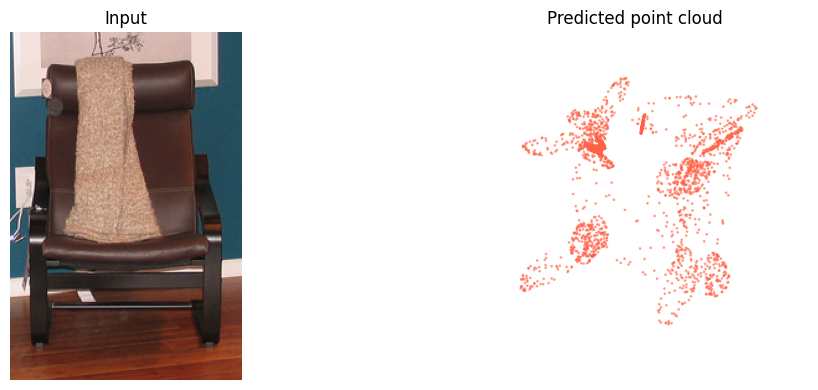

In [4]:
# ── change this to any chair photo ───────────────────────────────────────────
IMAGE_PATH = Path('../data/pix3d/img/chair/0001.png')
# ─────────────────────────────────────────────────────────────────────────────

TRANSFORM = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

img_pil = Image.open(IMAGE_PATH).convert('RGB')
img_t   = TRANSFORM(img_pil).unsqueeze(0).to(DEVICE)   # (1, 3, 224, 224)

with torch.no_grad():
    pts = model(img_t)[0].cpu().numpy()   # (2500, 3)

print('Point cloud shape:', pts.shape)

# preview
fig = plt.figure(figsize=(12, 4))

ax = fig.add_subplot(121)
ax.imshow(img_pil)
ax.set_title('Input')
ax.axis('off')

ax = fig.add_subplot(122, projection='3d')
ax.scatter(*pts.T, s=1, c='tomato', alpha=0.5)
ax.set_title('Predicted point cloud')
ax.set_box_aspect([1, 1, 1])
ax.set_axis_off()

plt.tight_layout()
plt.show()

## 4  Poisson surface reconstruction → OBJ

Open3D estimates normals then runs Poisson reconstruction.
`depth` controls mesh resolution (8 = fine, 6 = faster/coarser).
We trim low-density vertices to remove floaters.

In [5]:
POISSON_DEPTH   = 8     # increase for finer mesh, decrease if slow
DENSITY_QUANTILE = 0.05  # trim bottom 5% lowest-density vertices

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pts.astype(np.float64))

# estimate + orient normals toward camera
pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
pcd.orient_normals_consistent_tangent_plane(30)

mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    pcd, depth=POISSON_DEPTH
)

# remove low-density floaters
densities = np.asarray(densities)
keep = densities > np.quantile(densities, DENSITY_QUANTILE)
mesh.remove_vertices_by_mask(~keep)
mesh.compute_vertex_normals()

print(f'Mesh: {len(mesh.vertices)} vertices, {len(mesh.triangles)} triangles')

# save OBJ
stem    = IMAGE_PATH.stem
obj_out = OUT_DIR / f'{stem}.obj'
o3d.io.write_triangle_mesh(str(obj_out), mesh, write_ascii=True)
print('Saved:', obj_out.resolve())

Mesh: 11290 vertices, 22220 triangles
[Open3D WARNING] Write OBJ can not include triangle normals.
Saved: /Users/rx0/Desktop/FoundationOfAIML/2/generational-bullshit/GAN/exports/0001.obj


## 5  Preview mesh

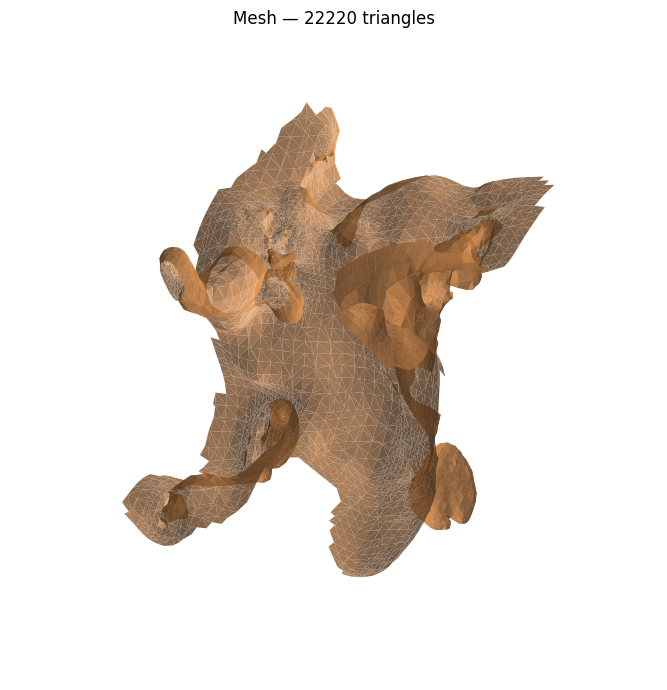

Next step: drag  /Users/rx0/Desktop/FoundationOfAIML/2/generational-bullshit/GAN/exports/0001.obj  into Reality Converter → export USDZ


In [6]:
verts = np.asarray(mesh.vertices)
tris  = np.asarray(mesh.triangles)

fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(
    verts[:, 0], verts[:, 1], verts[:, 2],
    triangles=tris,
    color='sandybrown', alpha=0.85, linewidth=0,
)
ax.set_title(f'Mesh — {len(tris)} triangles')
ax.set_box_aspect([1, 1, 1])
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f'Next step: drag  {obj_out.resolve()}  into Reality Converter → export USDZ')